In [30]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from underthesea import word_tokenize
from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from scipy.sparse import hstack
from sklearn.utils.class_weight import compute_sample_weight


In [31]:
with open("../dicts/vietnamese_stopwords.txt", "r", encoding="utf-8") as f:
    stopwords = set(
        line.strip()
        for line in f
        if line.strip() and not line.startswith("#")
    )

print("Số stopwords:", len(stopwords))

Số stopwords: 210


In [3]:

data_path = "../data/processed/"

train_df = pd.read_excel(os.path.join(data_path, "train.xlsx"))
dev_df   = pd.read_excel(os.path.join(data_path, "dev.xlsx"))
test_df  = pd.read_excel(os.path.join(data_path, "test.xlsx"))

X_train_raw = train_df["clean_review"]
y_train = train_df["label"]

X_dev_raw = dev_df["clean_review"]
y_dev = dev_df["label"]

X_test_raw = test_df["clean_review"]
y_test = test_df["label"]

print("Train size:", len(X_train_raw))
print("Dev size:", len(X_dev_raw))
print("Test size:", len(X_test_raw))

Train size: 42000
Dev size: 9000
Test size: 9000


In [32]:
def preprocess_text(text):
    tokens = word_tokenize(str(text).lower().strip(), format="text").split()
    tokens = [word for word in tokens if word not in stopwords] 
    return " ".join(tokens)

In [33]:
X_train = X_train_raw.apply(preprocess_text)
X_dev   = X_dev_raw.apply(preprocess_text)
X_test  = X_test_raw.apply(preprocess_text)

# Xem thử kết quả
print("Before:", X_train_raw.iloc[0])
print("After :", X_train.iloc[0])

Before: chất liệu vải đúng với mô tả đúng màu sắc đen hàng đẹp mỗi tội hơi bé nói chung đồ rẻ tiền thì như thế cũng ổn
After : chất_liệu vải đúng với mô_tả đúng đẹp mỗi tội hơi đồ rẻ_tiền như_thế cũng ổn


In [34]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.8,
    max_features= 30000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_dev_tfidf= vectorizer.transform(X_dev)
X_test_tfidf= vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (42000, 30000)


In [35]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [36]:
# NAIVE BAYES

nb_params = {"alpha":  [ 0.1, 0.2, 0.3, 0.5, 0.7, 1.0] }
best_score = 0
best_alpha = None
best_model = None
scores = []
alphas_used = []

for alpha in nb_params["alpha"]:
    # Khởi tạo mô hình với từng giá trị alpha
    model = MultinomialNB(alpha=alpha)
    
    # Huấn luyện trên Train có trọng số
    model.fit(X_train_tfidf, y_train, sample_weight=sample_weights)
    
    # Dự đoán trên Dev
    y_dev_pred = model.predict(X_dev_tfidf)
    
    # Tính Macro F1 trên Dev
    score = f1_score(y_dev, y_dev_pred, average='macro')
    
    scores.append(score)
    alphas_used.append(alpha)
    
    print(f"alpha = {alpha}, Macro F1 on Dev = {score:.3f}")
    
    # Lưu lại mô hình tốt nhất
    if score > best_score:
        best_score = score
        best_alpha = alpha
        best_model = model

print(f"\nBest alpha = {best_alpha}, Macro F1 on Dev = {best_score:.3f}")

alpha = 0.1, Macro F1 on Dev = 0.718
alpha = 0.2, Macro F1 on Dev = 0.719
alpha = 0.3, Macro F1 on Dev = 0.720
alpha = 0.5, Macro F1 on Dev = 0.720
alpha = 0.7, Macro F1 on Dev = 0.721
alpha = 1.0, Macro F1 on Dev = 0.723

Best alpha = 1.0, Macro F1 on Dev = 0.723


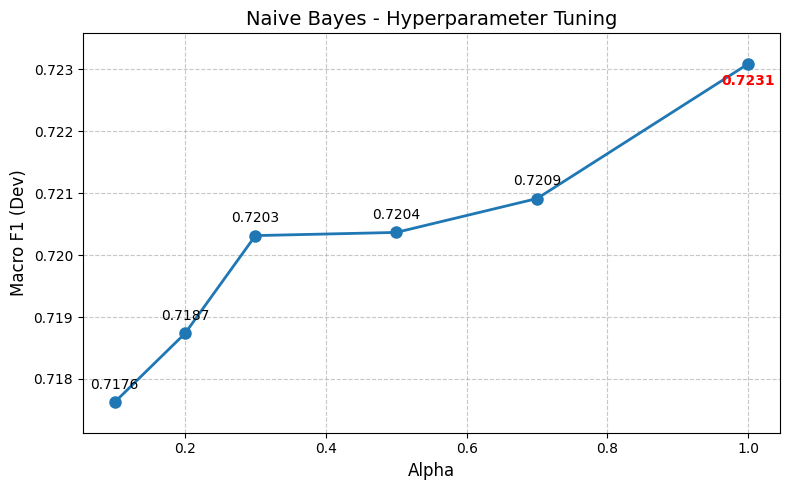

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(alphas_used, scores, marker='o', linestyle='-', linewidth=2, markersize=8)

plt.xlabel("Alpha", fontsize=12)
plt.ylabel("Macro F1 (Dev)", fontsize=12)
plt.title("Naive Bayes - Hyperparameter Tuning", fontsize=14)

best_idx = np.argmax(scores)
y_offset = (max(scores) - min(scores)) * 0.03

for i in range(len(alphas_used)):
    if i == best_idx:
        plt.text(alphas_used[i], scores[i] - y_offset, f"{scores[i]:.4f}",
                 ha='center', va='top', fontsize=10, fontweight='bold', color='red')
    else:
        plt.text(alphas_used[i], scores[i] + y_offset, f"{scores[i]:.4f}",
                 ha='center', va='bottom', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(min(scores) - y_offset*3, max(scores) + y_offset*3)
plt.tight_layout()
plt.show()


In [38]:
final_nb = MultinomialNB(alpha=best_alpha)
final_nb.fit(X_train_tfidf, y_train, sample_weight=sample_weights)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [39]:
# ĐÁNH GIÁ TRÊN DEV
y_dev_pred_final = final_nb.predict(X_dev_tfidf)
nb_dev_acc = accuracy_score(y_dev, y_dev_pred_final)
nb_dev_f1  = f1_score(y_dev, y_dev_pred_final, average='macro')

print("=== KẾT QUẢ NAIVE BAYES ===")
print(f"Dev  — Accuracy: {nb_dev_acc:.4f} | Macro F1: {nb_dev_f1:.4f}")
print("\nClassification Report (Dev):")
print(classification_report(y_dev, y_dev_pred_final, digits=4))

# ĐÁNH GIÁ TRÊN TEST
y_test_pred_nb = final_nb.predict(X_test_tfidf)
nb_test_acc = accuracy_score(y_test, y_test_pred_nb)
nb_test_f1  = f1_score(y_test, y_test_pred_nb, average='macro')

print(f"Test — Accuracy: {nb_test_acc:.4f} | Macro F1: {nb_test_f1:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_nb, digits=4))


=== KẾT QUẢ NAIVE BAYES ===
Dev  — Accuracy: 0.7347 | Macro F1: 0.7231

Classification Report (Dev):
              precision    recall  f1-score   support

           0     0.7992    0.7229    0.7591      3150
           1     0.5239    0.6676    0.5871      2250
           2     0.8627    0.7869    0.8231      3600

    accuracy                         0.7347      9000
   macro avg     0.7286    0.7258    0.7231      9000
weighted avg     0.7558    0.7347    0.7417      9000

Test — Accuracy: 0.7260 | Macro F1: 0.7151

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.7890    0.7229    0.7545      3150
           1     0.5161    0.6627    0.5803      2250
           2     0.8577    0.7683    0.8105      3600

    accuracy                         0.7260      9000
   macro avg     0.7209    0.7180    0.7151      9000
weighted avg     0.7482    0.7260    0.7334      9000



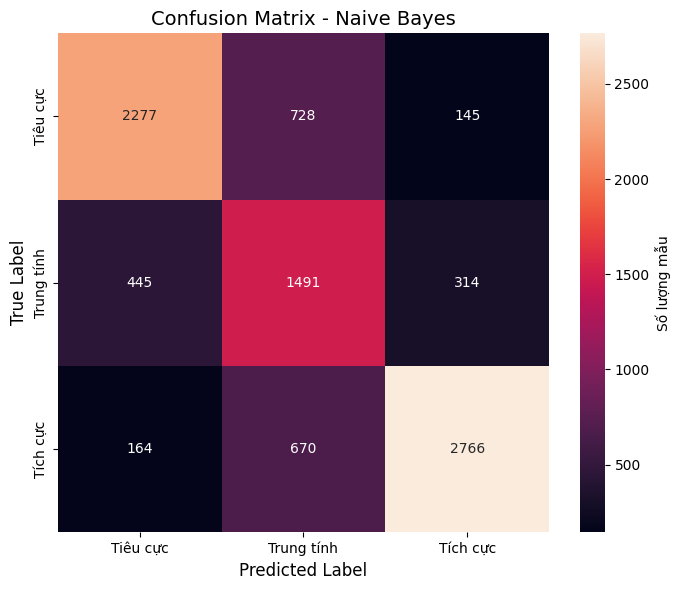

In [40]:
cm = confusion_matrix(y_test, y_test_pred_nb)
labels = ['Tiêu cực', 'Trung tính', 'Tích cực']

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'label': 'Số lượng mẫu'}
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - Naive Bayes", fontsize=14)
plt.tight_layout()
plt.show()


In [41]:
svm_params = {"C": [0.1, 0.5, 1, 5, 10]}

best_score = 0
best_C = None
best_model = None
scores = []
C_used = []

for C in svm_params["C"]:
    model = LinearSVC(C=C, random_state=42, max_iter=3000)
    
    model.fit(X_train_tfidf, y_train, sample_weight=sample_weights)
    
    y_dev_pred = model.predict(X_dev_tfidf)
   
    score = f1_score(y_dev, y_dev_pred, average='macro')
    
    scores.append(score)
    C_used.append(C)
    
    print(f"C = {C}, Macro F1 on Dev = {score:.4f}")
    
    # Lưu lại mô hình tốt nhất
    if score > best_score:
        best_score = score
        best_C = C
        best_model = model

print(f"\nBest C = {best_C}, Macro F1 on Dev = {best_score:.4f}")

C = 0.1, Macro F1 on Dev = 0.7486
C = 0.5, Macro F1 on Dev = 0.7456
C = 1, Macro F1 on Dev = 0.7373
C = 5, Macro F1 on Dev = 0.7129
C = 10, Macro F1 on Dev = 0.7030

Best C = 0.1, Macro F1 on Dev = 0.7486


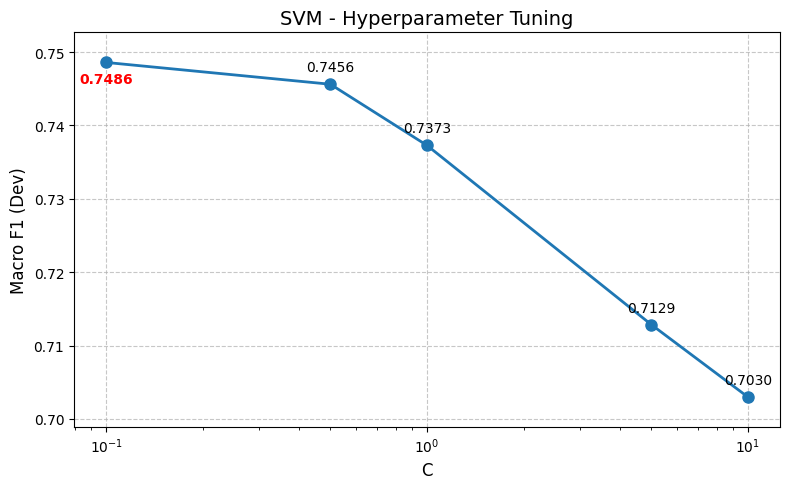

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(C_used, scores, marker='o', linestyle='-', linewidth=2, markersize=8)

plt.xlabel("C", fontsize=12)
plt.ylabel("Macro F1 (Dev)", fontsize=12)
plt.title("SVM - Hyperparameter Tuning", fontsize=14)
plt.xscale('log')

best_idx = np.argmax(scores)
y_offset = (max(scores) - min(scores)) * 0.03

for i in range(len(C_used)):
    if i == best_idx:
        plt.text(C_used[i], scores[i] - y_offset, f"{scores[i]:.4f}",
                 ha='center', va='top', fontsize=10, fontweight='bold', color='red')
    else:
        plt.text(C_used[i], scores[i] + y_offset, f"{scores[i]:.4f}",
                 ha='center', va='bottom', fontsize=10)

plt.ylim(min(scores) - y_offset*3, max(scores) + y_offset*3)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [43]:
final_svm = LinearSVC(C=best_C, random_state=42, max_iter=3000)
final_svm.fit(X_train_tfidf, y_train,sample_weight=sample_weights)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [44]:
# ĐÁNH GIÁ TRÊN DEV
y_dev_pred_final = final_svm.predict(X_dev_tfidf)
svm_dev_acc = accuracy_score(y_dev, y_dev_pred_final)
svm_dev_f1  = f1_score(y_dev, y_dev_pred_final, average='macro')

print("=== KẾT QUẢ SVM ===")
print(f"Dev  — Accuracy: {svm_dev_acc:.4f} | Macro F1: {svm_dev_f1:.4f}")
print("\nClassification Report (Dev):")
print(classification_report(y_dev, y_dev_pred_final, digits=4))

# ĐÁNH GIÁ TRÊN TEST
y_test_pred_svm = final_svm.predict(X_test_tfidf)
svm_test_acc = accuracy_score(y_test, y_test_pred_svm)
svm_test_f1  = f1_score(y_test, y_test_pred_svm, average='macro')

print(f"Test — Accuracy: {svm_test_acc:.4f} | Macro F1: {svm_test_f1:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_svm, digits=4))


=== KẾT QUẢ SVM ===
Dev  — Accuracy: 0.7656 | Macro F1: 0.7486

Classification Report (Dev):
              precision    recall  f1-score   support

           0     0.7928    0.7797    0.7862      3150
           1     0.5796    0.6329    0.6051      2250
           2     0.8737    0.8361    0.8545      3600

    accuracy                         0.7656      9000
   macro avg     0.7487    0.7496    0.7486      9000
weighted avg     0.7719    0.7656    0.7682      9000

Test — Accuracy: 0.7513 | Macro F1: 0.7341

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.7859    0.7784    0.7821      3150
           1     0.5580    0.6116    0.5835      2250
           2     0.8594    0.8150    0.8366      3600

    accuracy                         0.7513      9000
   macro avg     0.7344    0.7350    0.7341      9000
weighted avg     0.7583    0.7513    0.7543      9000



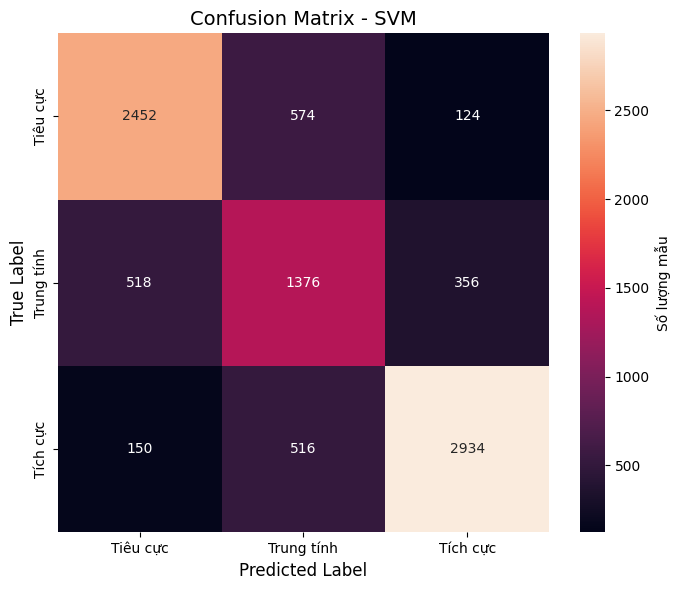

In [45]:
cm = confusion_matrix(y_test, y_test_pred_svm)
labels = ['Tiêu cực', 'Trung tính', 'Tích cực']

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'label': 'Số lượng mẫu'}
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - SVM", fontsize=14)
plt.tight_layout()
plt.show()


In [46]:
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20]
}

best_score = 0
best_params = None
best_model = None
results = []  # Lưu kết quả để vẽ biểu đồ

for n_est in rf_params["n_estimators"]:
    for max_depth in rf_params["max_depth"]:
        # Khởi tạo mô hình với từng bộ tham số
        model = RandomForestClassifier(
            n_estimators=n_est, 
            max_depth=max_depth,
            random_state=42,
            n_jobs=-1
        )
        
        # Huấn luyện trên Train
        model.fit(X_train_tfidf, y_train,sample_weight=sample_weights)
        
        # Dự đoán trên Dev
        y_dev_pred = model.predict(X_dev_tfidf)
        
        # Tính Macro F1 trên Dev
        score = f1_score(y_dev, y_dev_pred, average='macro')
        
        results.append({
            'n_estimators': n_est,
            'max_depth': max_depth,
            'macro_f1': score
        })
        
        print(f"n_estimators = {n_est}, max_depth = {max_depth}, Macro F1 on Dev = {score:.4f}")
        
        # Lưu lại mô hình tốt nhất
        if score > best_score:
            best_score = score
            best_params = {'n_estimators': n_est, 'max_depth': max_depth}
            best_model = model

print(f"\nBest params: n_estimators = {best_params['n_estimators']}, max_depth = {best_params['max_depth']}")
print(f"Best Macro F1 on Dev = {best_score:.4f}")

n_estimators = 50, max_depth = None, Macro F1 on Dev = 0.6960
n_estimators = 50, max_depth = 10, Macro F1 on Dev = 0.6565
n_estimators = 50, max_depth = 20, Macro F1 on Dev = 0.6788
n_estimators = 100, max_depth = None, Macro F1 on Dev = 0.7006
n_estimators = 100, max_depth = 10, Macro F1 on Dev = 0.6748
n_estimators = 100, max_depth = 20, Macro F1 on Dev = 0.6878
n_estimators = 200, max_depth = None, Macro F1 on Dev = 0.6976
n_estimators = 200, max_depth = 10, Macro F1 on Dev = 0.6791
n_estimators = 200, max_depth = 20, Macro F1 on Dev = 0.6915

Best params: n_estimators = 100, max_depth = None
Best Macro F1 on Dev = 0.7006


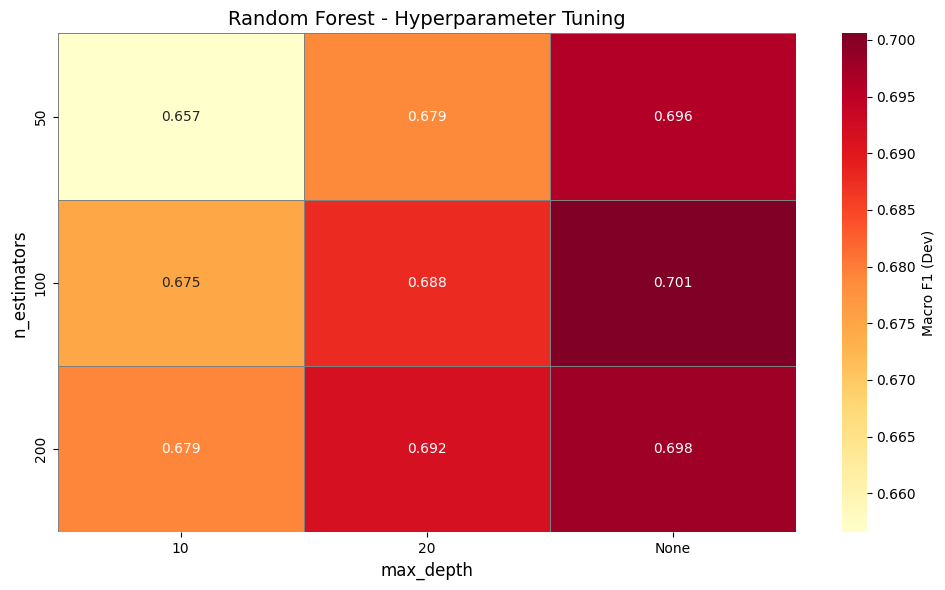

In [47]:

# Lấy giá trị unique
n_est_values = sorted(set([r['n_estimators'] for r in results]))

depth_values = sorted(
    set(r['max_depth'] for r in results),
    key=lambda x: (x is None, x)
)

# Chuyển None -> "None" để hiển thị
depth_values_display = ["None" if d is None else d for d in depth_values]

# Map kết quả để lookup nhanh
result_map = {
    (r['n_estimators'], "None" if r['max_depth'] is None else r['max_depth']): r['macro_f1']
    for r in results
}

# Tạo matrix 
score_matrix = np.full((len(n_est_values), len(depth_values)), np.nan)

for i, n_est in enumerate(n_est_values):
    for j, depth in enumerate(depth_values):
        depth_key = "None" if depth is None else depth
        score_matrix[i, j] = result_map.get((n_est, depth_key), np.nan)

# Vẽ heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    score_matrix,
    annot=True,
    fmt=".3f",
    xticklabels=depth_values_display,
    yticklabels=n_est_values,
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={'label': 'Macro F1 (Dev)'}
)

plt.xlabel("max_depth", fontsize=12)
plt.ylabel("n_estimators", fontsize=12)
plt.title("Random Forest - Hyperparameter Tuning", fontsize=14)

plt.tight_layout()
plt.show()

In [48]:
final_rf = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    random_state=42,
    n_jobs=-1
)
final_rf.fit(X_train_tfidf, y_train, sample_weight=sample_weights)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [49]:
# ĐÁNH GIÁ TRÊN DEV
y_dev_pred_final = final_rf.predict(X_dev_tfidf)
rf_dev_acc = accuracy_score(y_dev, y_dev_pred_final)
rf_dev_f1  = f1_score(y_dev, y_dev_pred_final, average='macro')

print("=== KẾT QUẢ RANDOM FOREST ===")
print(f"Dev  — Accuracy: {rf_dev_acc:.4f} | Macro F1: {rf_dev_f1:.4f}")
print("\nClassification Report (Dev):")
print(classification_report(y_dev, y_dev_pred_final, digits=4))

# ĐÁNH GIÁ TRÊN TEST
y_test_pred_rf = final_rf.predict(X_test_tfidf)
rf_test_acc = accuracy_score(y_test, y_test_pred_rf)
rf_test_f1  = f1_score(y_test, y_test_pred_rf, average='macro')

print(f"Test — Accuracy: {rf_test_acc:.4f} | Macro F1: {rf_test_f1:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_rf, digits=4))


=== KẾT QUẢ RANDOM FOREST ===
Dev  — Accuracy: 0.7387 | Macro F1: 0.7006

Classification Report (Dev):
              precision    recall  f1-score   support

           0     0.7415    0.8187    0.7782      3150
           1     0.6152    0.4213    0.5001      2250
           2     0.7840    0.8669    0.8234      3600

    accuracy                         0.7387      9000
   macro avg     0.7136    0.7023    0.7006      9000
weighted avg     0.7269    0.7387    0.7268      9000

Test — Accuracy: 0.7340 | Macro F1: 0.6973

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.7284    0.8241    0.7733      3150
           1     0.6171    0.4240    0.5026      2250
           2     0.7856    0.8489    0.8160      3600

    accuracy                         0.7340      9000
   macro avg     0.7104    0.6990    0.6973      9000
weighted avg     0.7234    0.7340    0.7227      9000



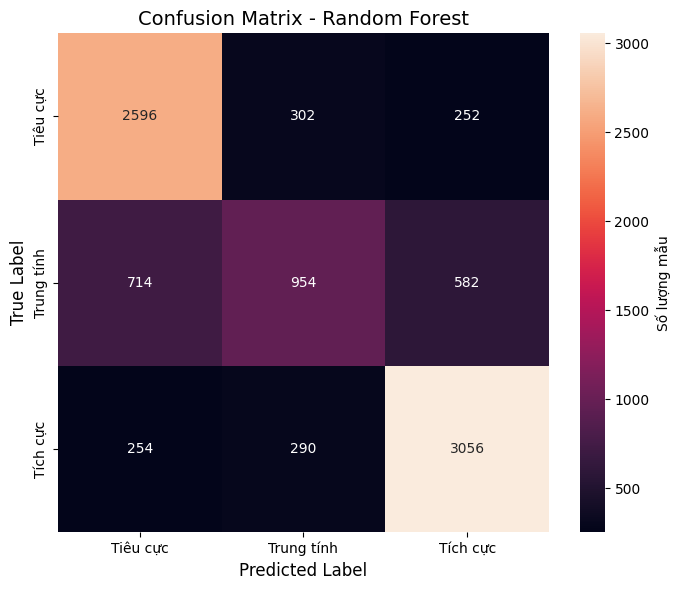

In [50]:
cm = confusion_matrix(y_test, y_test_pred_rf)
labels = ['Tiêu cực', 'Trung tính', 'Tích cực']

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'label': 'Số lượng mẫu'}
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - Random Forest", fontsize=14)
plt.tight_layout()
plt.show()


In [51]:
# =========================
# BẢNG SO SÁNH TỔNG HỢP
# =========================

summary = pd.DataFrame({
    "Mô hình":       ["Naive Bayes", "SVM", "Random Forest"],
    "Dev Accuracy":  [nb_dev_acc,  svm_dev_acc,  rf_dev_acc],
    "Dev Macro F1":  [nb_dev_f1,   svm_dev_f1,   rf_dev_f1],
    "Test Accuracy": [nb_test_acc, svm_test_acc, rf_test_acc],
    "Test Macro F1": [nb_test_f1,  svm_test_f1,  rf_test_f1],
})

for col in ["Dev Accuracy", "Dev Macro F1", "Test Accuracy", "Test Macro F1"]:
    summary[col] = summary[col].map("{:.4f}".format)

display(summary.style
    .set_caption("Kết quả so sánh các mô hình")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-size", "14px"), ("font-weight", "bold")]}])
    .apply(lambda col: [
        "background-color: #d4edda; font-weight: bold"
        if v == col.max() else "" for v in col
    ], subset=["Dev Macro F1", "Test Macro F1"])
)


,Mô hình,Dev Accuracy,Dev Macro F1,Test Accuracy,Test Macro F1
0,Naive Bayes,0.7347,0.7231,0.7260,0.7151
1,SVM,0.7656,0.7486,0.7513,0.7341
2,Random Forest,0.7387,0.7006,0.7340,0.6973
